# Evac-Sim — Project Overview & Representative Scenarios

This notebook is an executable companion to the project [`README.md`](../README.md) and to the
research paper this repository implements:

> Á. Serrano, M. Lujak, G. Vizzari, "When shortest is not safest: Multi-agent evacuation with
> awareness and agile routing in dynamic hazards", *Simulation Modelling Practice and Theory*,
> vol. 150, 2026, 103294. https://doi.org/10.1016/j.simpat.2026.103294

It covers three things:

1. **Objectives** — what question this project is trying to answer, and how.
2. **Structure** — how the codebase is organized, and how it maps to the paper's three-module
   architecture (Risk / Routing / Agent simulation).
3. **Representative scenarios** — it actually runs the three `configs/study.yaml` scenarios
   discussed in the paper (`example_case`, `representative_case`, `representative_case_theme_park`)
   and inspects their real output.

**This notebook runs real simulations.** Each scenario uses `risk.risk_iterations: 7000`, whose
precomputation (not the agent movement itself) dominates the runtime — expect several minutes per
scenario depending on hardware, not a fixed number of seconds.

> **Note on numbers**: the tables/figures in the paper were produced from a specific, tagged
> commit (`d1098b3`, see the README's "Version Used for the SIMPAT Paper" section). Running these
> scenarios from the current `HEAD` reproduces the same *methodology* (same scenarios, same
> metrics), but the exact numeric results shown below are **not** guaranteed to match the published
> tables — the code may have evolved since that commit.

## 1. Objectives

The central research question is: **once a hazard (fire, smoke, flooding, ...) starts spreading
dynamically and unpredictably during an evacuation, is the shortest route still the safest one to
guide people through?**

The project studies this under an *ambient-intelligence* assumption: sensors detect pedestrians and
hazards, and evacuees receive real-time route guidance (variable message panels, mobile apps) that
they are assumed to follow. Two things are varied independently to study their effect on evacuation
outcomes:

- **Situational awareness** — how much of the evolving hazard an evacuee group perceives:
  - **low / reactive**: the group only checks whether the *next* node on its route is dangerous.
  - **high / anticipatory**: the group checks its *entire remaining route* and reroutes as soon as
    any future node becomes dangerous.
- **Routing strategy** — how a new route is chosen once rerouting is triggered:
  - **efficient**: always the nominally fastest route (shortest path, Dijkstra).
  - **agile (centrality-based)**: prefers structurally well-connected routes (high *evacuation
    betweenness centrality*) that keep more rerouting options open if the hazard keeps spreading.

Crossing these two axes gives **four guidance configurations**, evaluated with:

- **Evacuation-time metrics**: max / average / median / p90 evacuation time per group.
- **Remaining-path risk (RPR)**: mean, variance, and max of the time-dependent, node-level risk
  along a group's *remaining* route (excluding the current and destination nodes) at each decision
  point — this is the paper's main safety indicator.

The headline result: **higher situational awareness consistently improves both evacuation time and
safety**, and **agile routing is especially valuable under low awareness and in spatially complex
environments**, where it reduces risk exposure without a meaningful time penalty.

## 2. Setup

Same pattern as `docs/management_building_api_walkthrough.ipynb`: resolve the project root, put
`src/` on `sys.path`, and define a couple of helpers to call the `evac-sim` CLI as a subprocess and
print its real output.

In [1]:
from pathlib import Path
import json
import shutil
import subprocess
import sys

import pandas as pd
import yaml
from IPython.display import IFrame, Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for parent in [current, *current.parents]:
        if (parent / ".git").exists():
            return parent
    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

EVAC_SIM = PROJECT_ROOT / ".venv" / "Scripts" / "evac-sim.exe"
if not EVAC_SIM.exists():
    EVAC_SIM = "evac-sim"  # fall back to PATH (non-Windows / other envs)

OUTPUT_ROOT = PROJECT_ROOT / "runs" / "notebook_study_demo"
STUDY_CONFIG = "configs/study.yaml"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"EVAC_SIM:     {EVAC_SIM}")
print(f"OUTPUT_ROOT:  {OUTPUT_ROOT}")

PROJECT_ROOT: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
EVAC_SIM:     C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe
OUTPUT_ROOT:  C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo


In [2]:
def run_cli(*args: str) -> subprocess.CompletedProcess:
    """Run `evac-sim <args>` as a subprocess, print the command and its output."""
    cmd = [str(EVAC_SIM), *args]
    print("$ " + " ".join(cmd))
    result = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    print(f"[exit code: {result.returncode}]")
    return result


def fresh_dir(path: Path) -> Path:
    """evac-sim run requires --output-dir to be empty if it already exists."""
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

## 3. Project structure

```
Evacuation_Simulation/
├── configs/                    # scenario YAML files (see configs/CONFIG_REFERENCE.md)
│   ├── study.yaml               #   corridor / cruise_ship / theme_park research scenarios
│   ├── management_building.yaml #   basement / floor_0 / floor_1 scenarios
│   ├── defaults.yaml            #   shared defaults merged into every scenario
│   └── CONFIG_REFERENCE.md      #   full field-by-field reference for the YAML schema
│
├── docs/                       # extended documentation + executable notebooks (this file)
├── Notebooks/                  # interactive exploration / visualization notebooks
├── manuals/                    # PDF user manuals
├── tools/                      # standalone analysis scripts
├── results/ , runs/            # simulation outputs (git-ignored)
│
├── src/evac_sim/                # the `evac_sim` package
│   ├── cli.py                   #   entry point for `evac-sim` (run / validate / inspect)
│   ├── runner.py                #   orchestrates a full run from a YAML case
│   ├── envs/                    #   graph-based environment representation + scenario registry
│   ├── risk/                    #   Risk Simulation Module
│   ├── routing/                 #   Routing Module
│   ├── simulation/               #   Agent Simulation Module
│   ├── orchestration/            #   wires risk + routing + simulation together per experiment
│   ├── core/                    #   shared data model (SimulationConfig, AgentGroup, ...)
│   ├── db/                      #   SQLite persistence
│   ├── analysis/ , metrics/      #   post-hoc evacuation/risk/density metrics
│   ├── io/                      #   YAML config loading/merging, run-directory & logging setup
│   └── viz/                     #   Plotly/matplotlib plots and animations
│
├── tests/
├── pyproject.toml
└── README.md
```

Let's confirm this against the actual filesystem rather than trusting the diagram above.

In [3]:
def print_tree(root: Path, prefix: str = "", max_depth: int = 1, depth: int = 0) -> None:
    entries = sorted(
        [p for p in root.iterdir() if p.name not in {"__pycache__", ".git"}],
        key=lambda p: (p.is_file(), p.name),
    )
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(f"{prefix}{connector}{entry.name}")
        if entry.is_dir() and depth < max_depth:
            extension = "    " if i == len(entries) - 1 else "│   "
            print_tree(entry, prefix + extension, max_depth, depth + 1)


print(f"{PROJECT_ROOT}/")
print_tree(PROJECT_ROOT, max_depth=0)
print()
print(f"{PROJECT_ROOT / 'src' / 'evac_sim'}/")
print_tree(PROJECT_ROOT / "src" / "evac_sim", max_depth=0)

C:\Users\aserr\Documentos\Githup\Evacuation_Simulation/
├── .claude
├── .idea
├── .pytest_cache
├── .venv
├── Notebooks
├── configs
├── docs
├── latex_projects
├── manuals
├── results
├── runs
├── src
├── tests
├── tools
├── .gitignore
├── LICENCE
├── README.md
└── pyproject.toml

C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\src\evac_sim/
├── analysis
├── core
├── db
├── envs
├── io
├── metrics
├── orchestration
├── risk
├── routing
├── simulation
├── viz
├── __init__.py
├── __main__.py
├── cli.py
├── info.txt
└── runner.py


## 4. Three-module architecture

Section 4 of the paper describes the simulation as three modules operating on a shared graph-based
environment:

| Paper module | Code package | Role |
|---|---|---|
| **Risk Simulation Module** | `evac_sim/risk/` | Computes the temporal/spatial evolution of hazards over the graph: propagation, decay, thresholds. Produces a time-indexed risk map `r(v, t)`. |
| **Routing Module** | `evac_sim/routing/` | Computes/updates evacuation paths from the graph, the risk map, and each group's routing strategy + awareness level (efficient vs. agile/centrality-based). |
| **Agent Simulation Module** | `evac_sim/simulation/` | Executes JuPedSim's microscopic pedestrian movement, frame by frame, for leader-based agent groups. |

All three share the same graph-based environment, defined in `evac_sim/envs/` (`Environment` =
graph + geometry + a registry of concrete scenarios such as `corridor`, `cruise_ship`,
`theme_park`, `management_building_*`, ...).

`evac_sim/orchestration/` is the glue layer: `experiment_setup.py`/`experiment_runner.py` read a
YAML case, build the environment/groups/risk/congestion configuration, and drive the
risk → routing → simulation loop described above — this is what `evac-sim run` ultimately calls.

Supporting infrastructure sits around these layers:

- `core/` — shared data model (`SimulationConfig`, `AgentGroup`, `EnvironmentInfo`, ...).
- `db/` — SQLite persistence of trajectories, risk levels, and experiment metrics.
- `analysis/` + `metrics/` — post-hoc computation of evacuation/risk/density metrics from the DB.
- `io/` — YAML config loading/merging and run-directory/logging setup.
- `viz/` — Plotly/matplotlib plots and animations.

This matches the paper's three-level decision-making framework (Section 4.6): the **strategic**
level is the initial environment/graph/hazard configuration (`envs/`); the **tactical** level is
route selection and adaptation (`routing/`, informed by `risk/`); the **operational** level is the
continuous execution of pedestrian movement (`simulation/`).

## 5. Routing strategy × awareness: the `mode_type` field

Every scenario in `configs/study.yaml` sets `mode_type`, which selects which combination(s) of
**algorithm** (efficient = shortest path, agile = centrality-based) and **awareness** (low, high)
are simulated. Each selected mode is a full, independent repetition of the simulation, from the same
initial agent assignment (see `configs/CONFIG_REFERENCE.md`, section 3, for the authoritative
version of this table):

| `mode_type` | Modes run | Meaning |
|---|---|---|
| `0` | efficient/low, efficient/high, agile/low, agile/high | all 4 combinations at once |
| `1` | 2 modes | **special case**: two groups get a *different* strategy assigned by their `sources` index, each simulated at low and high awareness — this is exactly the two-group dynamic-hazard scenario in Section 6.1 of the paper (`example_case` below) |
| `2` | efficient/low, efficient/high | efficient routing, awareness comparison only |
| `3` | agile/low, agile/high | agile routing, awareness comparison only |
| `4` | agile/low | agile / low awareness only |
| `5` | efficient/high | efficient / high awareness only (recommended for a single "best guess" run) |
| `6` | agile/high | agile / high awareness only |

The three scenarios we run below use `mode_type: 1` (`example_case`) and `mode_type: 0`
(`representative_case`, `representative_case_theme_park`) — i.e. they run 2 and 4 simulation passes
respectively, from the same starting positions, one pass per routing/awareness configuration.

## 6. The three scenarios

Section 5 of the paper motivates using structurally rich environments — simple single-corridor
layouts trivialize routing decisions, so the study instead uses:

- **Cruise ship** — narrow corridors, compartmentalized areas, structural bottlenecks. Amplifies
  the effect of congestion and hazard propagation; routing decisions have immediate consequences.
- **Theme park** — wide corridors, open intersections, multiple converging routes. High structural
  redundancy; good for studying how strategies distribute agents across space.

`configs/study.yaml` defines, among others, the three scenarios discussed in Sections 6.1–6.2 of the
paper:

| Scenario key | Environment | `mode_type` | Role in the paper |
|---|---|---|---|
| `example_case` | `cruise_ship` | `1` | Section 6.1 — two groups (Blue = one strategy, Red = the other) evacuating as **two separate hazards emerge sequentially**; illustrates rerouting behavior in detail. |
| `representative_case` | `cruise_ship` | `0` | Section 6.2 — the representative Cruise Ship scenario, run under all 4 routing/awareness configurations (Fig. 7 / Table 6). |
| `representative_case_theme_park` | `theme_park` | `0` | Section 6.2 — the representative Theme Park scenario, run under all 4 routing/awareness configurations (Fig. 6 / Table 5). |

In [4]:
with open(PROJECT_ROOT / STUDY_CONFIG, encoding="utf-8") as f:
    study_yaml = yaml.safe_load(f)

STUDY_SCENARIOS = ["example_case", "representative_case", "representative_case_theme_park"]

for name in STUDY_SCENARIOS:
    case = study_yaml[name]
    print(f"{name}:")
    print(f"  environment: {case['environment']}")
    print(f"  sources:     {case['sources']}")
    print(f"  agents:      {case['agents']} (total: {sum(case['agents'])})")
    print(f"  targets:     {case['targets']}")
    print(f"  mode_type:   {case['mode_type']}")
    print()

example_case:
  environment: cruise_ship
  sources:     ['82', '83']
  agents:      [5, 5] (total: 10)
  targets:     ['163', '164']
  mode_type:   1

representative_case:
  environment: cruise_ship
  sources:     ['82', '83', '73', '77', '92']
  agents:      [5, 5, 6, 6, 10] (total: 32)
  targets:     ['163', '164']
  mode_type:   0

representative_case_theme_park:
  environment: theme_park
  sources:     ['1', '4', '35', '50']
  agents:      [13, 7, 6, 4] (total: 30)
  targets:     ['65', '23']
  mode_type:   0



## 7. Validate the scenarios

As in `docs/management_building_api_walkthrough.ipynb`, we validate before running.

In [5]:
for scenario in STUDY_SCENARIOS:
    result = run_cli("validate", "--config", STUDY_CONFIG, "--scenario", scenario)
    assert result.returncode == 0, f"{scenario} should be VALID"
    print()

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe validate --config configs/study.yaml --scenario example_case



Scenario: example_case
Status:   VALID

[exit code: 0]

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe validate --config configs/study.yaml --scenario representative_case



Scenario: representative_case
Status:   VALID

[exit code: 0]

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe validate --config configs/study.yaml --scenario representative_case_theme_park



Scenario: representative_case_theme_park
Status:   VALID

[exit code: 0]



## 8. Run the scenarios

Each scenario is run with `--output-format json,csv,html` so we get a structured `result.json` plus
an interactive Plotly replay per simulated mode. `example_case` runs 2 modes, the two
`representative_case*` scenarios run 4 modes each — all sharing a single risk pre-simulation per
scenario.

In [6]:
results_by_scenario = {}

for scenario in STUDY_SCENARIOS:
    out_dir = fresh_dir(OUTPUT_ROOT / scenario)
    result = run_cli(
        "run",
        "--config", STUDY_CONFIG,
        "--scenario", scenario,
        "--output-dir", str(out_dir),
        "--output-format", "json,csv,html",
    )
    assert result.returncode == 0, f"The {scenario} simulation should complete"

    with (out_dir / "result.json").open(encoding="utf-8") as f:
        results_by_scenario[scenario] = json.load(f)

    print()

print("Scenarios simulated:", list(results_by_scenario))

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe run --config configs/study.yaml --scenario example_case --output-dir C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\example_case --output-format json,csv,html


JSON result written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\example_case\result.json
CSV files written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\example_case
HTML animations written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\example_case\artifacts\animations

2026-07-14 11:53:51,178 | INFO | evac_sim.runner | Selected 1 case = example_case
2026-07-14 11:53:51,179 | INFO | evac_sim.runner | project_root = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
2026-07-14 11:53:51,179 | INFO | evac_sim.runner | config_file  = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\study.yaml
2026-07-14 11:53:51,179 | INFO | evac_sim.runner | case_id      = example_case
2026-07-14 11:53:51,179 | INFO | evac_sim.runner | run_dir      = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\example_case
2026-07-14 11:53:51,392 | INFO |

JSON result written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representative_case\result.json
CSV files written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representative_case
HTML animations written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representative_case\artifacts\animations

2026-07-14 11:56:28,940 | INFO | evac_sim.runner | Selected 1 case = representative_case
2026-07-14 11:56:28,956 | INFO | evac_sim.runner | project_root = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
2026-07-14 11:56:28,956 | INFO | evac_sim.runner | config_file  = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\study.yaml
2026-07-14 11:56:28,956 | INFO | evac_sim.runner | case_id      = representative_case
2026-07-14 11:56:28,956 | INFO | evac_sim.runner | run_dir      = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representa


$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe run --config configs/study.yaml --scenario representative_case_theme_park --output-dir C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representative_case_theme_park --output-format json,csv,html


JSON result written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representative_case_theme_park\result.json
CSV files written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representative_case_theme_park
HTML animations written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_study_demo\representative_case_theme_park\artifacts\animations

2026-07-14 11:59:30,173 | INFO | evac_sim.runner | Selected 1 case = representative_case_theme_park
2026-07-14 11:59:30,173 | INFO | evac_sim.runner | project_root = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
2026-07-14 11:59:30,173 | INFO | evac_sim.runner | config_file  = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\study.yaml
2026-07-14 11:59:30,173 | INFO | evac_sim.runner | case_id      = representative_case_theme_park
2026-07-14 11:59:30,173 | INFO | evac_sim.runner | run_dir      = C:\Users\aserr\Documentos\Githup\Ev

## 9. Results

For each scenario, `summary.groups[]` reports one row per (source group × simulated mode), with the
evacuation-time statistics and risk-exposure metrics described in Section 3.4 of the paper. This is
the same underlying data used to build Tables 2, 5, and 6 in the article — the exact numbers will
differ from those tables (different code version, see the note at the top of this notebook), but the
structure and the qualitative pattern (higher awareness → lower risk exposure) should hold.

In [7]:
for scenario in STUDY_SCENARIOS:
    result = results_by_scenario[scenario]
    print(f"=== {scenario} ({result['environment']}) — status: {result['status']} ===")
    summary_df = pd.json_normalize(result["summary"], sep=".").drop(columns=["groups"], errors="ignore")
    display(summary_df)
    groups_df = pd.json_normalize(result["summary"]["groups"])
    display(groups_df)
    print()

=== example_case (cruise_ship) — status: completed ===


,total_agents,evacuated_agents,not_evacuated_agents,evacuation_time,average_evacuation_time,max_evacuation_time,total_frames
0,10,1139,0,182.97,145.076,182.97,6099


,group_id,algorithm,n_evacuated,avg_time,median_time,p90_time,min_time,max_time,cumulative_risk_exposure
0,82,Efficient,117,173.59,173.58,174.588,172.35,174.84,0.028244
1,83,Centrality,101,149.66,149.67,150.798,148.23,151.08,0.020428
2,82__lag,Efficient,116,182.97,182.97,182.970,182.97,182.97,0.041844
3,83__lag,Centrality,98,166.50,166.50,166.500,166.50,166.50,0.038659
4,83__lag_2,Centrality,100,171.18,171.18,171.180,171.18,171.18,0.054677
5,82__lag_2,Efficient,102,182.79,182.79,182.790,182.79,182.79,0.040691
6,82,Efficient,68,100.95,100.95,100.950,100.95,100.95,0.027280
7,83,Centrality,79,116.46,116.46,117.036,115.74,117.18,0.002548
8,83__lag,Centrality,69,123.75,123.75,123.750,123.75,123.75,0.000000
9,83__lag_2,Centrality,66,120.69,120.69,120.690,120.69,120.69,0.002982



=== representative_case (cruise_ship) — status: completed ===


,total_agents,evacuated_agents,not_evacuated_agents,evacuation_time,average_evacuation_time,max_evacuation_time,total_frames
0,32,4630,0,131.97,98.738,131.97,4399


,group_id,algorithm,n_evacuated,avg_time,median_time,p90_time,min_time,max_time,cumulative_risk_exposure
0,73,Efficient,79,117.735,117.735,118.227,117.12,118.35,0.004219
1,77,Efficient,46,68.160,68.160,68.160,68.16,68.16,0.023397
2,92,Efficient,56,81.315,81.315,82.263,80.13,82.50,0.020955
3,82,Efficient,77,113.370,113.370,114.066,112.50,114.24,0.016720
4,83,Efficient,67,98.790,98.790,99.438,97.98,99.60,0.026307
...,...,...,...,...,...,...,...,...,...
92,92__lag_4,Centrality,30,90.570,90.570,90.570,90.57,90.57,0.018893
93,92__lag__lag_2,Centrality,32,102.960,102.960,102.960,102.96,102.96,0.019418
94,77__lag_4,Centrality,15,81.600,81.600,81.600,81.60,81.60,0.018934
95,73__lag_4,Centrality,8,94.770,94.770,94.770,94.77,94.77,0.004167



=== representative_case_theme_park (theme_park) — status: completed ===


,total_agents,evacuated_agents,not_evacuated_agents,evacuation_time,average_evacuation_time,max_evacuation_time,total_frames
0,30,645,0,47.97,26.029,47.97,1599


,group_id,algorithm,n_evacuated,avg_time,median_time,p90_time,min_time,max_time,cumulative_risk_exposure
0,35,Efficient,15,19.680,19.680,20.736,18.36,21.00,0.039683
1,4,Efficient,18,24.100,24.060,25.284,22.65,25.59,0.056645
2,50,Efficient,12,16.240,16.260,17.364,14.82,17.64,0.212121
3,1,Efficient,21,29.340,29.340,29.892,28.65,30.03,0.043360
4,35__lag,Efficient,13,24.990,24.990,24.990,24.99,24.99,0.052288
5,1__lag,Efficient,23,41.410,41.400,42.480,40.08,42.75,0.019841
6,50__lag,Efficient,6,19.020,19.020,19.020,19.02,19.02,0.213675
7,4__lag,Efficient,17,37.350,37.350,37.350,37.35,37.35,0.115556
8,35__lag_2,Efficient,7,23.670,23.670,23.670,23.67,23.67,0.069444
9,35__lag_3,Efficient,5,22.350,22.350,22.350,22.35,22.35,0.044444


### A closer look at `example_case`

This is the dynamic hazard expansion scenario from Section 6.1: two groups (`sources[0]="82"`,
`sources[1]="83"`), each assigned a different routing strategy by its source index, evacuating while
two separate hazards emerge in sequence. `groups[].algorithm` shows which strategy JuPedSim actually
used for each group/mode pass.

In [8]:
example_case_result = results_by_scenario["example_case"]
example_groups_df = pd.json_normalize(example_case_result["summary"]["groups"])
display(example_groups_df[["group_id", "algorithm", "n_evacuated", "avg_time", "max_time", "cumulative_risk_exposure"]])

,group_id,algorithm,n_evacuated,avg_time,max_time,cumulative_risk_exposure
0,82,Efficient,117,173.59,174.84,0.028244
1,83,Centrality,101,149.66,151.08,0.020428
2,82__lag,Efficient,116,182.97,182.97,0.041844
3,83__lag,Centrality,98,166.50,166.50,0.038659
4,83__lag_2,Centrality,100,171.18,171.18,0.054677
5,82__lag_2,Efficient,102,182.79,182.79,0.040691
6,82,Efficient,68,100.95,100.95,0.027280
7,83,Centrality,79,116.46,117.18,0.002548
8,83__lag,Centrality,69,123.75,123.75,0.000000
9,83__lag_2,Centrality,66,120.69,120.69,0.002982


## 10. Trajectories and risk visualization

`evac-sim run` also writes static trajectory/density images and — since we asked for `html` — an
interactive Plotly replay per mode, the same kind of visualization used to produce Figs. 6 and 7 in
the paper. Let's look at the representative Theme Park scenario (Fig. 6 in the paper).

Generated images:
  - Theme Park_mode_0_density.png
  - Theme Park_mode_0_trajectories.png
  - Theme Park_mode_1_density.png
  - Theme Park_mode_1_trajectories.png
  - Theme Park_mode_2_density.png
  - Theme Park_mode_2_trajectories.png
  - Theme Park_mode_3_density.png
  - Theme Park_mode_3_trajectories.png


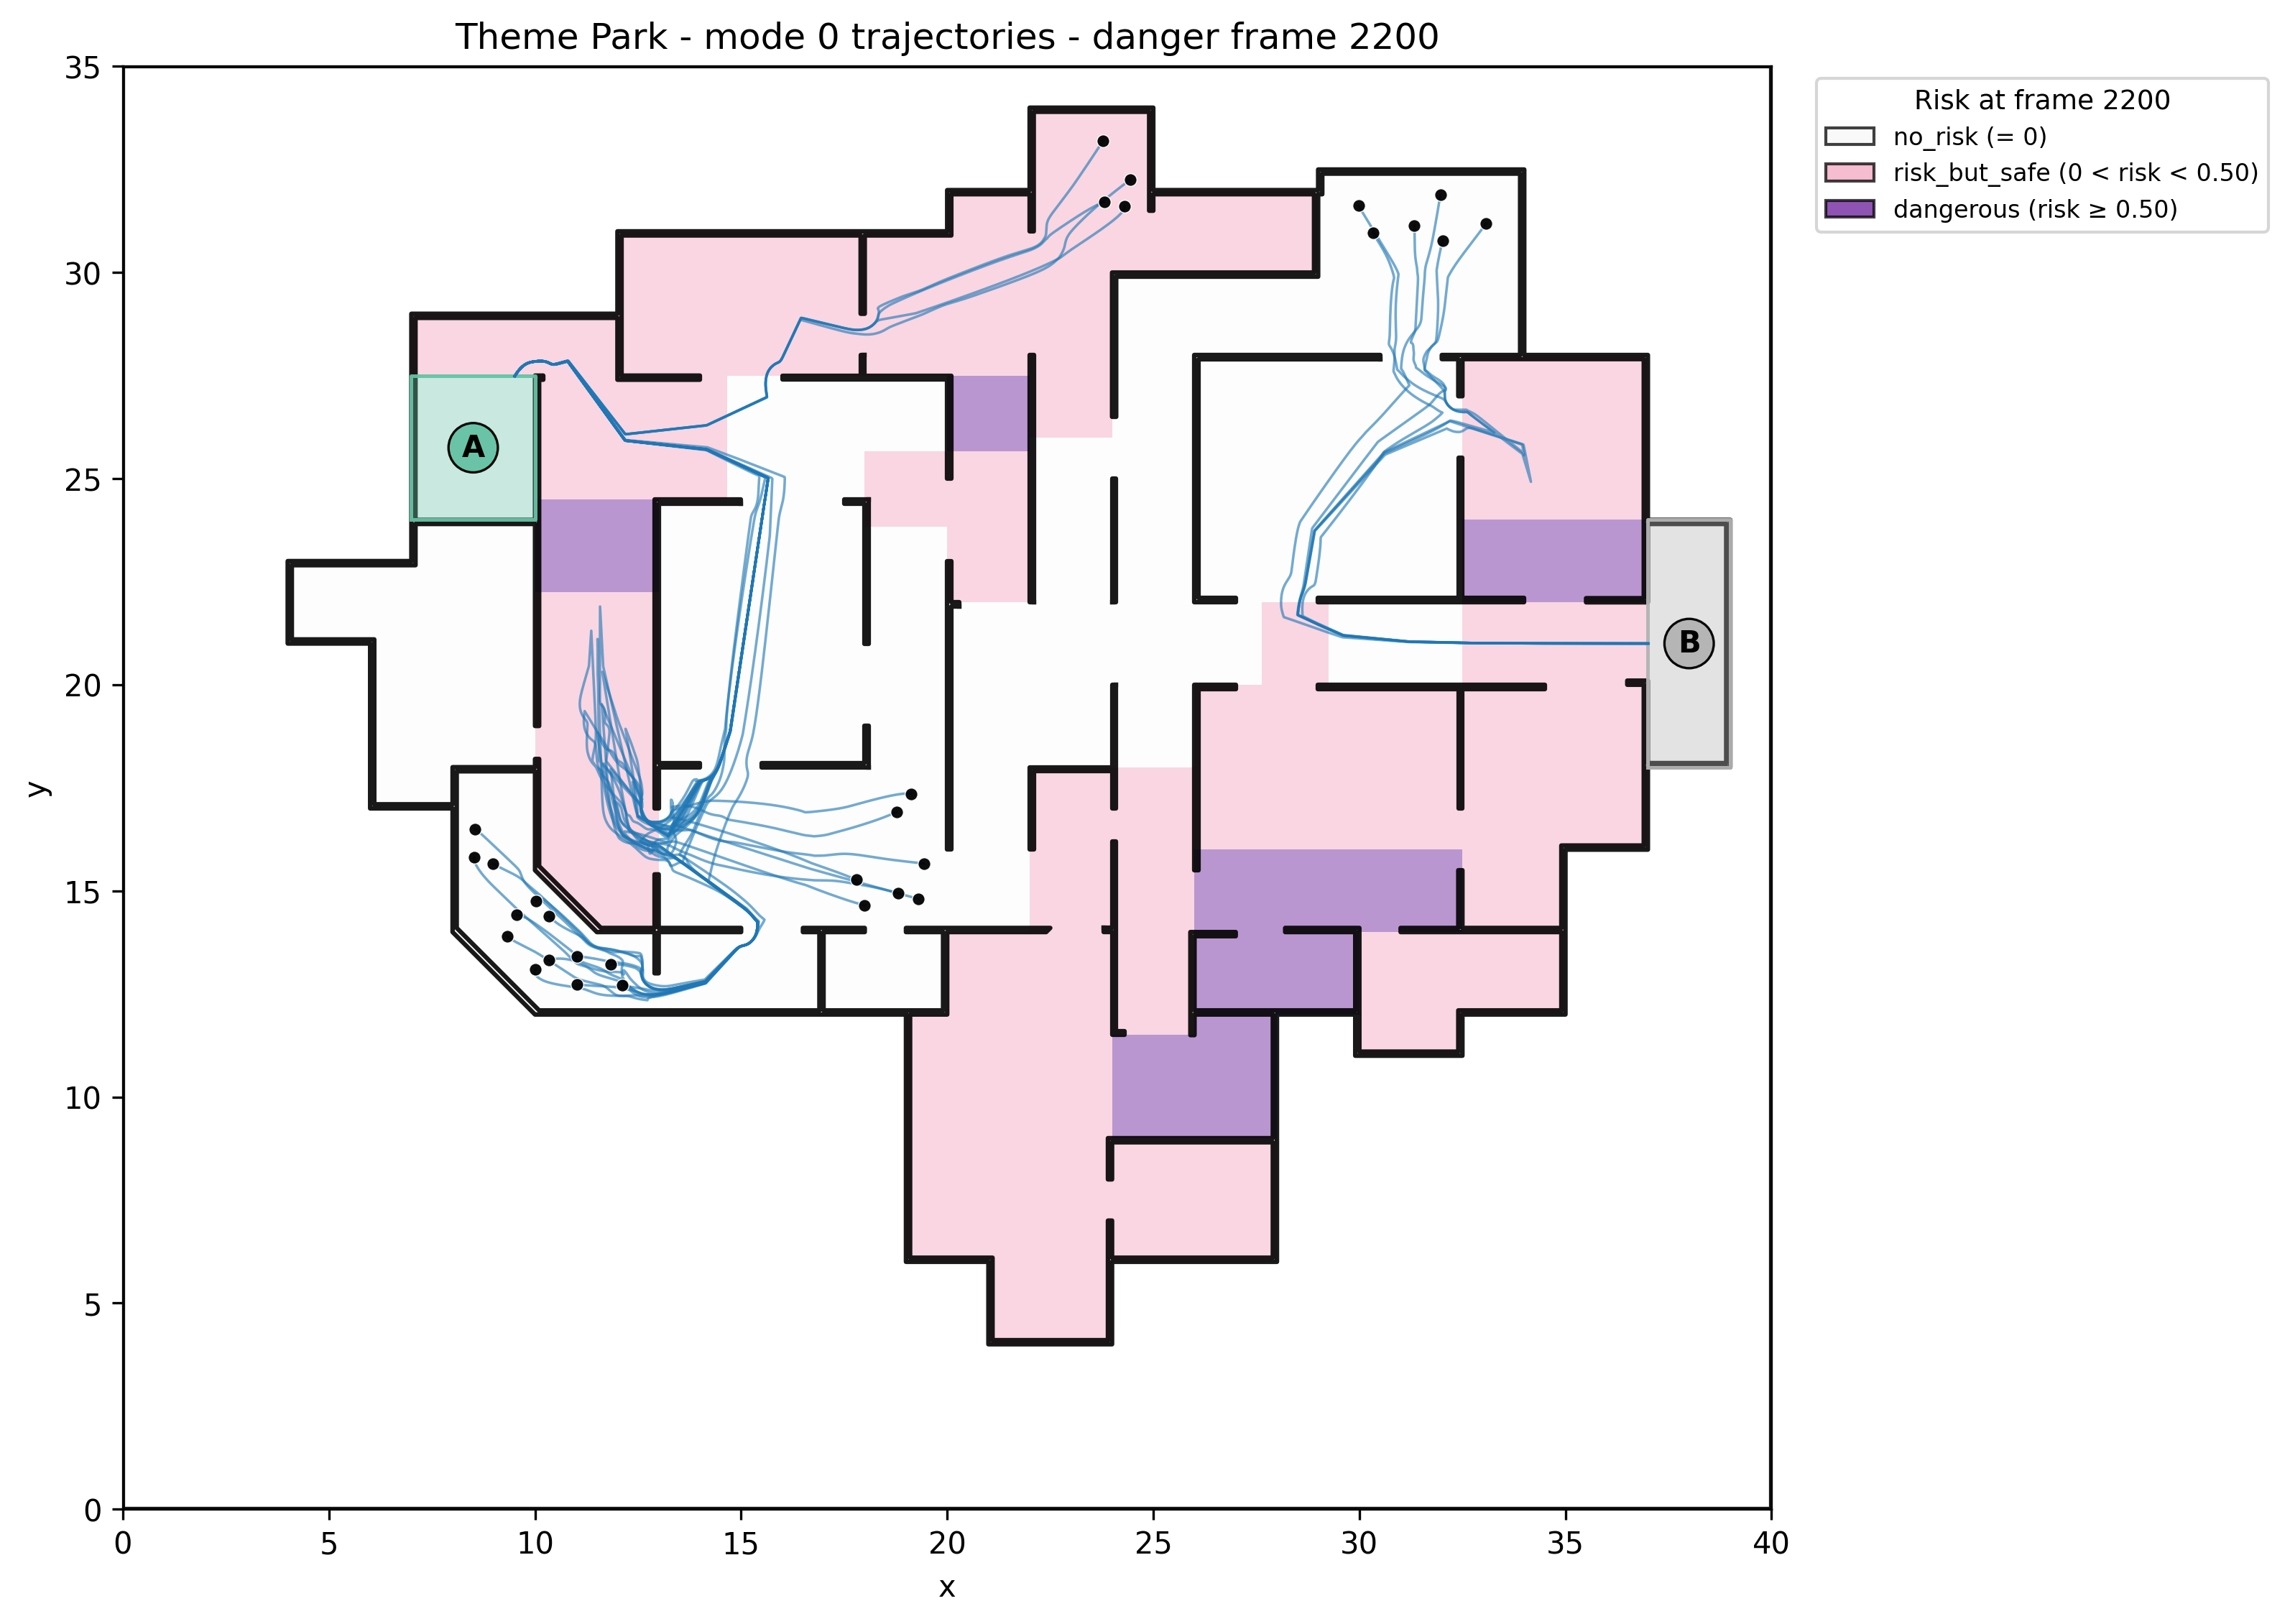

In [9]:
theme_park_dir = OUTPUT_ROOT / "representative_case_theme_park"
images_dir = theme_park_dir / "artifacts" / "images"
image_files = sorted(images_dir.glob("*.png"))

print("Generated images:")
for p in image_files:
    print(f"  - {p.name}")

trajectory_images = [p for p in image_files if "trajector" in p.name.lower()]
if trajectory_images:
    display(Image(filename=str(trajectory_images[0])))

In [10]:
animations_dir = theme_park_dir / "artifacts" / "animations"
animation_files = sorted(animations_dir.glob("*.html"))
print("Interactive replays generated:")
for p in animation_files:
    print(f"  - {p.relative_to(PROJECT_ROOT)}")

if animation_files:
    display(IFrame(src=str(animation_files[0]), width="100%", height=500))

Interactive replays generated:
  - runs\notebook_study_demo\representative_case_theme_park\artifacts\animations\theme_park_mode_0.html
  - runs\notebook_study_demo\representative_case_theme_park\artifacts\animations\theme_park_mode_1.html
  - runs\notebook_study_demo\representative_case_theme_park\artifacts\animations\theme_park_mode_2.html
  - runs\notebook_study_demo\representative_case_theme_park\artifacts\animations\theme_park_mode_3.html


## 11. Summary

This notebook:

- Explained the project's research objective (does situational awareness and agile routing improve
  evacuation safety under dynamic hazards?) and its evaluation metrics (evacuation time, RPR).
- Mapped the codebase's `risk/` / `routing/` / `simulation/` / `orchestration/` packages onto the
  paper's three-module architecture.
- Explained the `mode_type` field and how it maps onto the paper's routing-strategy ×
  awareness-level configurations.
- Actually validated and ran the three `configs/study.yaml` scenarios referenced in Sections 6.1–6.2
  of the paper (`example_case`, `representative_case`, `representative_case_theme_park`), and
  inspected their real `result.json` output and visual artifacts.

All generated artifacts live under `runs/notebook_study_demo/` (git-ignored). For the full
`evac-sim` CLI reference, see [`docs/SCRIPTS_REFERENCE.md`](SCRIPTS_REFERENCE.md); for a walkthrough
focused on driving the CLI from an external interface, see
[`docs/management_building_api_walkthrough.ipynb`](management_building_api_walkthrough.ipynb).